# Create Rasters

This is an example of how to use the ASI algorithm within NWtrace using a synthetic raster & fixed inlet/outfall locations based on:

Choi, Yosoon, Huiuk Yi, and Hyeong-Dong Park. “A New Algorithm for Grid-Based Hydrologic Analysis by Incorporating Stormwater Infrastructure.” Computers & Geosciences 37, no. 8 (2011): 1035–44. https://doi.org/10.1016/j.cageo.2010.07.008.

This notebook creates a temporary directory to hold intermittent .tif/raster files that is deleted at the end. Do not run the first cell more than once without restarting as this will create additional temporary directories. DO NOT change the 'temp'/working directory to a directory that has files that you care about, they WILL be deleted.

In [ ]:
import os
import numpy as np
import rasterio as rio
from rasterio.transform import from_origin
from whitebox import WhiteboxTools
from pathlib import Path

from nwtrace import ASI
from nwtrace import raster_utils

wbt = WhiteboxTools()

starting_dir = Path(os.path.abspath('.'))
working_dir = os.path.join('temp')

if not os.path.exists(working_dir):
    os.mkdir(working_dir)
    
wbt.set_working_dir(path_str=working_dir)
os.chdir(working_dir)

# This sets whether to force sinks at inlet locations after DEM smoothing to influence flow
install_inlets = True
# If true, will fill sinks after d8_pointer processing with the original cell value
fill_after = False

# set what value to give artificial sinks
sink_value = 0

In [2]:
# sample DEM from (Choi et al., 2011)
dem = np.array([
    [98, 98, 99, 95, 94, 86, 92, 96, 99, 102],  # y = 1
    [89, 64, 62, 62, 89, 91, 89, 98, 98, 100],  # y = 2
    [85, 53, 51, 59, 80, 90, 88, 82, 92, 96],   # y = 3
    [89, 84, 72, 64, 67, 70, 80, 87, 94, 94],   # y = 4
    [84, 85, 92, 96, 94, 90, 81, 79, 81, 92],   # y = 5
    [72, 82, 87, 92, 92, 83, 78, 84, 76, 90],   # y = 6
    [64, 64, 66, 69, 79, 88, 84, 78, 84, 88],   # y = 7
    [72, 80, 77, 69, 62, 70, 83, 79, 78, 84],   # y = 8
    [71, 79, 80, 80, 77, 64, 62, 67, 70, 76],   # y = 9
    [55, 53, 61, 80, 80, 80, 70, 62, 66, 67],   # y = 10
], dtype=np.float32)

inlet_locs = [(2,2)]
outfall_locs = [(8,1)]

original_sink_values = [51]

# 2. Write to GeoTIFF so WhiteboxTools can read it

# define an arbitrary transform: origin at (0, 0), cell size = 1 unit
transform = from_origin(west=0, north=10, xsize=1, ysize=1)

# name of temporary fire for storing the DEM
dem_filename = "synthetic_dem.tif"

with rio.open(
    dem_filename,
    'w',
    driver='GTiff',
    height=dem.shape[0],
    width=dem.shape[1],
    count=1,
    dtype=dem.dtype,
    crs="+proj=latlong",   # you can pick any CRS; for synthetic DEM it's not critical
    transform=transform,
) as dst:
    dst.write(dem, 1)

print("DEM written to", dem_filename)

DEM written to synthetic_dem.tif


In [3]:
# Hydrologically prepare the input DEM

working_file = "smoothed_dem.tif"

# planchon and darboux gives the closest approximation to the dem shown in the Choi paper
wbt.fill_depressions_planchon_and_darboux(
    dem=dem_filename,
    output=working_file,
    fix_flats=True,
    flat_increment=0.01
)

.\whitebox_tools.exe --run="FillDepressionsPlanchonAndDarboux" --wd="c:\Users\gameg\OneDrive - Toronto Metropolitan University (TMU)\Documents\RA\nwtrace\examples\temp" --dem='synthetic_dem.tif' --output='smoothed_dem.tif' --fix_flats --flat_increment='0.01' -v --compress_rasters=False

************************************************
* Welcome to FillDepressionsPlanchonAndDarboux *
* Powered by WhiteboxTools                     *
* www.whiteboxgeo.com                          *
************************************************
Reading data...
progress (Loop 1): 11%
progress (Loop 1): 22%
progress (Loop 1): 33%
progress (Loop 1): 44%
progress (Loop 1): 55%
progress (Loop 1): 66%
progress (Loop 1): 77%
progress (Loop 1): 88%
Loop 1 (Num. modified cells: 129)
progress (Loop 2): 22%
progress (Loop 2): 33%
progress (Loop 2): 44%
progress (Loop 2): 55%
progress (Loop 2): 66%
progress (Loop 2): 77%
progress (Loop 2): 88%
progress (Loop 2): 100%
Loop 2 (Num. modified cells: 33)
progress (Loop 

0

In [4]:

# force sinks at inlet locations
if install_inlets and not fill_after:

    # Restore the original sink value
    with rio.open(working_file) as src:
        filled = src.read(1)

    for inlet in inlet_locs:
        filled[inlet[0], inlet[1]] = sink_value

    # Save final DEM
    with rio.open(
        working_file, "w",
        driver="GTiff",
        height=filled.shape[0],
        width=filled.shape[1],
        count=1,
        dtype=filled.dtype,
        crs="+proj=latlong",
        transform=transform
    ) as dst:
        dst.write(filled.astype("float32"), 1)

In [5]:
# Create the flow direction raster
out_flow_dir = "flow_dir_d8.tif"
wbt.d8_pointer(
    dem=working_file,
    output=out_flow_dir,
    esri_pntr=False
)

# restore real raster values at inlet locations after installing sinks
if install_inlets and fill_after:
    # Restore the original sink value
    with rio.open(out_flow_dir) as src:
        filled = src.read(1)

    for i, inlet in enumerate(inlet_locs):
        filled[inlet[0], inlet[1]] = original_sink_values[i]

    # Save final DEM
    with rio.open(
        out_flow_dir, "w",
        driver="GTiff",
        height=filled.shape[0],
        width=filled.shape[1],
        count=1,
        dtype=filled.dtype,
        crs="+proj=latlong",
        transform=transform
    ) as dst:
        dst.write(filled.astype("float32"), 1)

.\whitebox_tools.exe --run="D8Pointer" --wd="c:\Users\gameg\OneDrive - Toronto Metropolitan University (TMU)\Documents\RA\nwtrace\examples\temp" --dem='smoothed_dem.tif' --output='flow_dir_d8.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 11%
Progress: 22%
Progress: 33%
Progress: 44%
Progress: 55%
Progress: 66%
Progress: 77%
Progress: 88%
Progress: 100%
Saving data...
Output file written
Elapsed Time (excluding I/O): 0.0s


In [6]:
# Convert the flow direction raster to SAGA format
conversion = raster_utils.conversions.whitebox_to_saga

# read the WhiteboxTools D8 pointer raster
out_raster = "flow_dir_saga_d8.tif"

with rio.open(out_flow_dir) as src:
    arr = src.read(1)
    profile = src.profile

# convert using vectorized lookup
# create a new array with same shape
saga_arr = np.zeros_like(arr, dtype=np.int32)

for wbt_code, saga_code in conversion.items():
    saga_arr[arr == wbt_code] = saga_code

# write output raster
profile.update(dtype=rio.int32)

with rio.open(out_raster, "w", **profile) as dst:
    dst.write(saga_arr, 1)

print("Converted SAGA-format D8 pointer raster written to:", out_raster)

Converted SAGA-format D8 pointer raster written to: flow_dir_saga_d8.tif


In [7]:
# Perform flow accumulation

working_file = "flow_dir_d8.tif"
acc_output = "flow_acc.tif"

wbt.d8_flow_accumulation(
    working_file,
    acc_output
)

.\whitebox_tools.exe --run="D8FlowAccumulation" --wd="c:\Users\gameg\OneDrive - Toronto Metropolitan University (TMU)\Documents\RA\nwtrace\examples\temp" --input='flow_dir_d8.tif' --output='flow_acc.tif' --out_type=cells -v --compress_rasters=False

*********************************
* Welcome to D8FlowAccumulation *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************
Reading data...
Flow directions: 0%
Flow directions: 11%
Flow directions: 22%
Flow directions: 33%
Flow directions: 44%
Flow directions: 55%
Flow directions: 66%
Flow directions: 77%
Flow directions: 88%
Flow directions: 100%
Num. inflowing neighbours: 0%
Num. inflowing neighbours: 11%
Num. inflowing neighbours: 22%
Num. inflowing neighbours: 33%
Num. inflowing neighbours: 44%
Num. inflowing neighbours: 55%
Num. inflowing neighbours: 66%
Num. inflowing neighbours: 77%
Num. inflowing neighbours: 88%
Num. inflowing neighbours: 100%
Flow accumulation: 1%
Flow accumulation: 2%


0

# Display Rasters

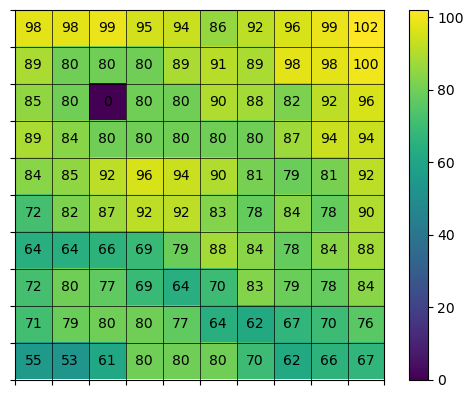

In [8]:
# Display the dem raster
raster_utils.display_raster("smoothed_dem.tif")

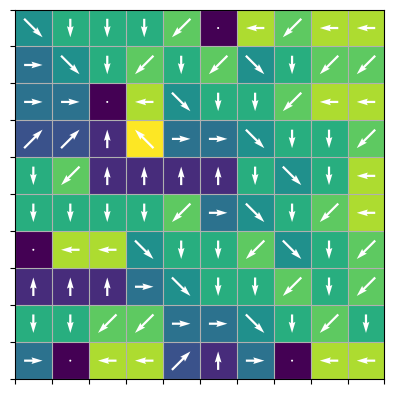

In [9]:
# Display flow direction
raster_utils.display_raster_direction("flow_dir_saga_d8.tif", d8_vector_conversion=raster_utils.conversions.saga_to_vector)

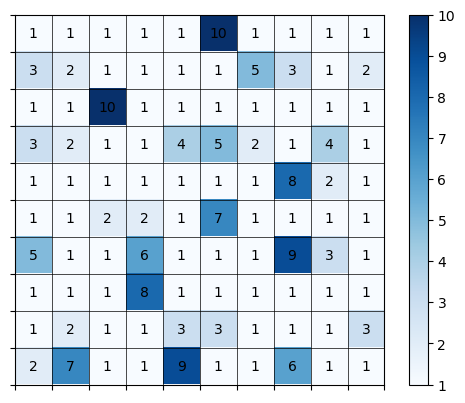

In [10]:
# Display the Flow Accumulation
raster_utils.display_raster("flow_acc.tif", cmap="Blues")

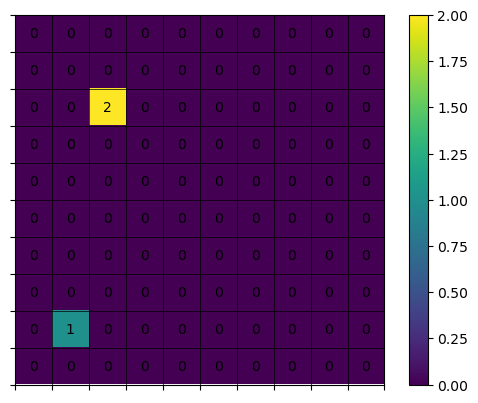

In [11]:
# show the locations of inlets and outfalls
in_out_locations = np.zeros_like(dem)

for r,c in outfall_locs:
    in_out_locations[r,c] = 1
    
for r,c in inlet_locs:
    in_out_locations[r,c] = 2

raster_utils.display_raster(in_out_locations)

# Run ASI

In [12]:
# create proper format tables for outfalls & inlets
outfall_locations = {
    (8,1): "OF1"
}

inlet_locations = {
    "IN1": (2,2)
}

inlet_connections = {
    "OF1": ["IN1"],
}

with rio.open("flow_dir_d8.tif") as src:
    d8_arr = src.read(1)
    profile = src.profile

# set option for watershed type (Options: "OUTLET", "INLET", "OUTFALL")
watershed_type = "OUTFALL"

In [13]:
sewershed = ASI(
    d8_flow_direction_raster = d8_arr,
    inlet_connections=inlet_connections,
    outfall_locations=outfall_locations,
    inlet_locations=inlet_locations,
    watershed_type=watershed_type
)

In [14]:
# create an inlet mask that indicates the locations of inlets in the dataset so they can be excluded from the list of seed cells
inlet_mask = np.zeros_like(d8_arr)

# find seed cells as starting points for accumulation
for r,c in inlet_locations.values():
    inlet_mask[r,c] = 1

seeds = sewershed.get_seed_cells(d8_arr, inlet_mask)

seeds

[(np.int64(0), np.int64(5)),
 (np.int64(6), np.int64(0)),
 (np.int64(9), np.int64(1)),
 (np.int64(9), np.int64(7))]

In [15]:
for r,c in seeds:
    sewershed.iterative_asi(r,c,f"{r}_{c}")

In [16]:
sewershed.watershed_table

{'0_5': 0, '6_0': 1, '9_1': 2, 'OF1': 3, '9_7': 4}

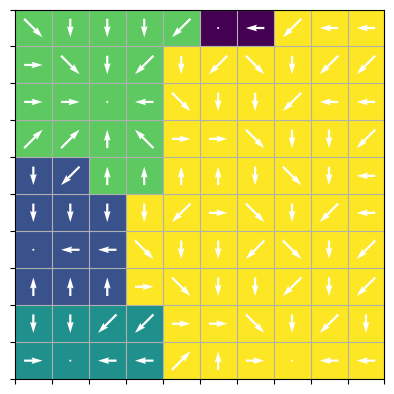

In [17]:
raster_utils.display_raster_direction(sewershed.d8_dir, base_ras=sewershed.d8_watershed, d8_vector_conversion=sewershed.direction_map)

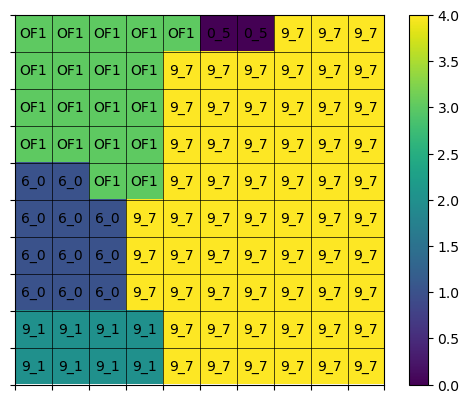

In [18]:
# display the watersheds with proper labels
inv_map = {v: k for k, v in sewershed.watershed_table.items()}

raster_utils.display_raster(sewershed.d8_watershed, label_table=inv_map)

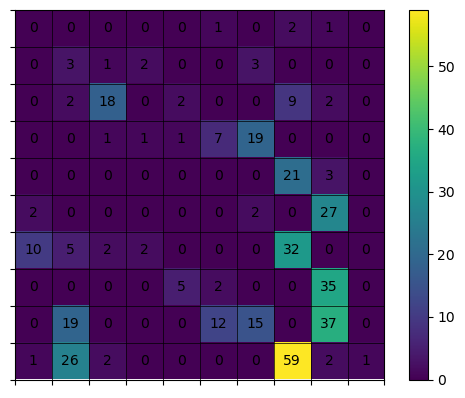

In [19]:
raster_utils.display_raster(sewershed.d8_accum)

In [20]:
import shutil

# return to main directory and delete temporary files
os.chdir(starting_dir)
wbt.set_working_dir(starting_dir)

os.chmod(working_dir, 0o777)
shutil.rmtree(working_dir)